### EDA de séries temporais — Sistema MIMO (tempo, frequência, identificação de sistemas)

Análise exploratória focada em propriedades de série temporal da série MIMO
(reservatório), complementando `01_exploracao_reservatorio_mimo.ipynb`:
tendência/decomposição, estacionariedade, autocorrelação, causalidade de
Granger, cointegração, DTW/clustering, shapelets, domínio da frequência e
identificação de sistemas (ARX).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dtaidistance import dtw
from scipy import signal
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen

from mimo_sys.preprocessors import TimeSeriesPreprocessor

sns.set_theme(style="whitegrid")

DATA_PROCESSED = Path("../../data/processed")
FEATURE_COLS = [
    "freq_b1",
    "freq_b2",
    "freq_b3",
    "vazao_entrada",
    "vazao_distribuicao",
    "nivel_res",
    "pressao",
]
INPUT_COLS = ["freq_b1", "freq_b2", "freq_b3", "vazao_entrada"]
OUTPUT_COLS = ["vazao_distribuicao", "nivel_res", "pressao"]

In [2]:
mimo_raw = pd.read_parquet(DATA_PROCESSED / "mimo_data.parquet")
mimo_raw = mimo_raw[FEATURE_COLS]
mimo_raw.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2216 entries, 2014-07-27 01:00:00 to 2014-10-27 09:00:00
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   freq_b1             2208 non-null   float64
 1   freq_b2             2208 non-null   float64
 2   freq_b3             2208 non-null   float64
 3   vazao_entrada       2208 non-null   float64
 4   vazao_distribuicao  2208 non-null   float64
 5   nivel_res           2208 non-null   float64
 6   pressao             2208 non-null   float64
dtypes: float64(7)
memory usage: 138.5 KB


Há poucos valores ausentes (8 por coluna, em 2216 amostras). Imputamos por
interpolação antes das análises abaixo — os testes estatísticos (ADF, Granger,
cointegração) e o `TimeSeriesPreprocessor` exigem séries sem `NaN`/`inf`.

In [3]:
mimo = mimo_raw.interpolate().ffill().bfill()
assert not mimo.isna().any().any()

#### Distribuições e correlação (visão geral)

/tmp/ipykernel_13682/700616801.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i, 1].boxplot(mimo[col], vert=False)
/tmp/ipykernel_13682/700616801.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i, 1].boxplot(mimo[col], vert=False)
/tmp/ipykernel_13682/700616801.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i, 1].boxplot(mimo[col], vert=False)
/tmp/ipykernel_13682/700616801.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i, 1].boxplot(mimo[col], vert=False)
/tmp/ipykernel_13682/700616801.py:5: MatplotlibDepre

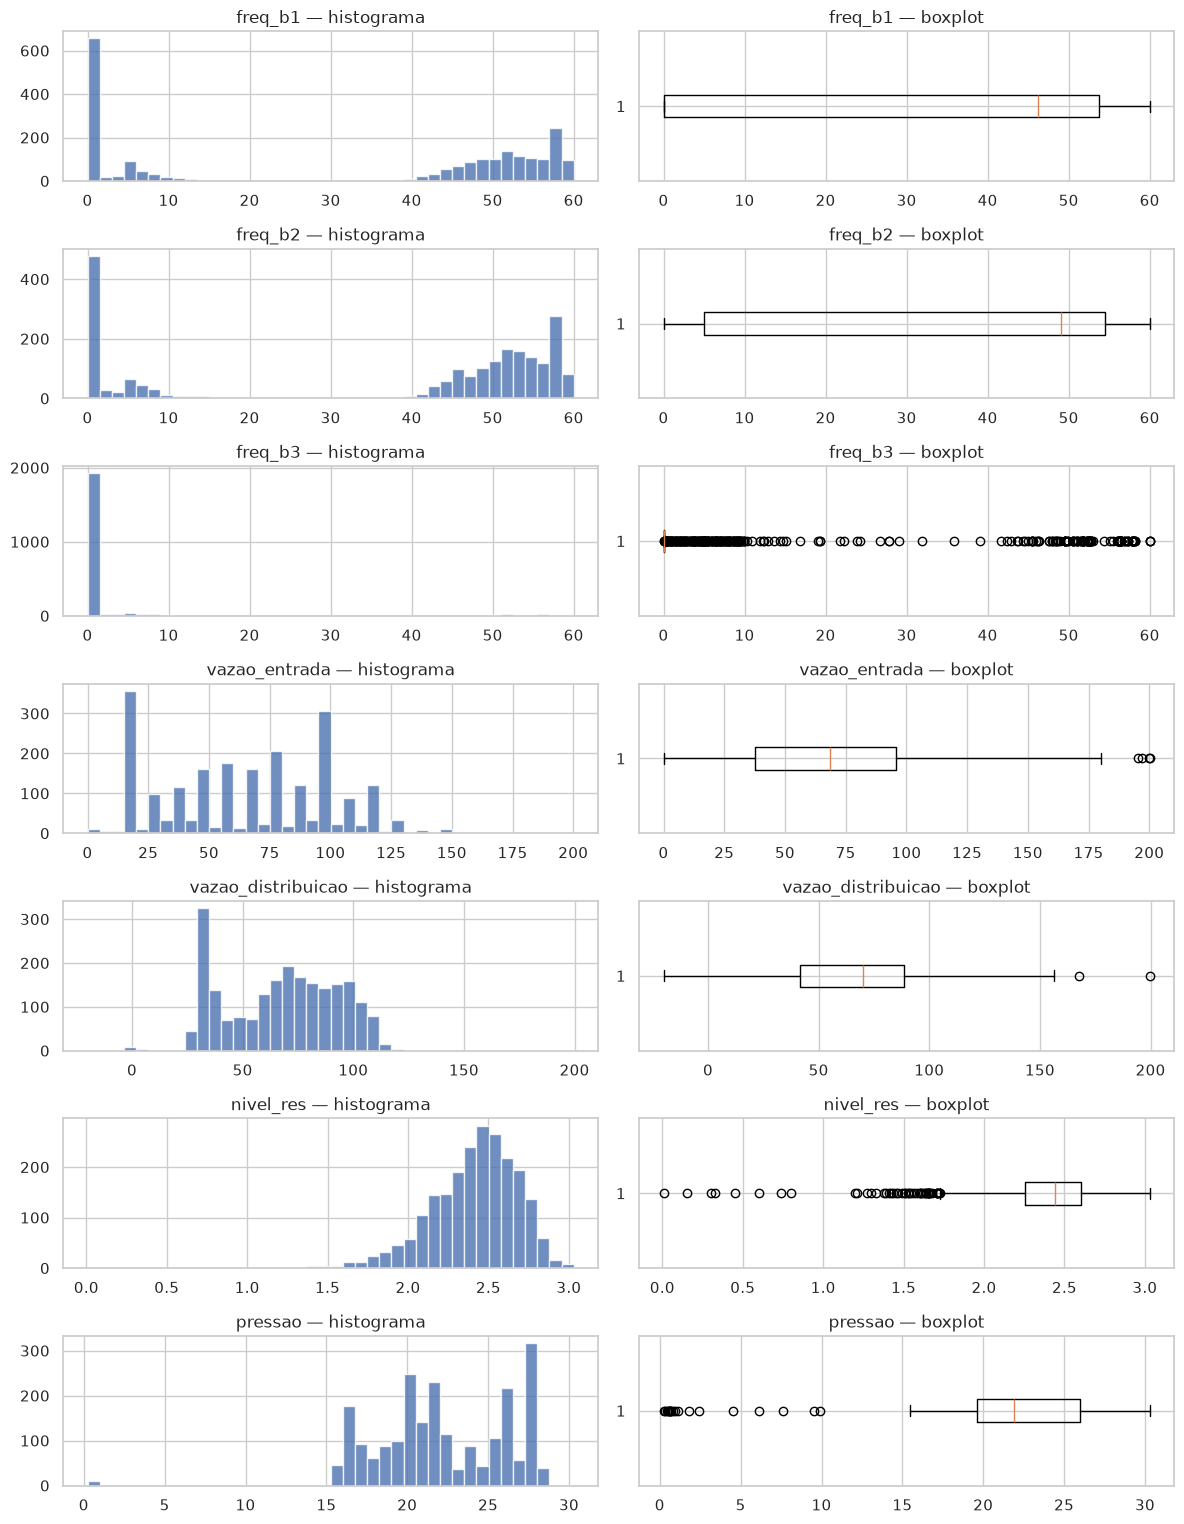

In [4]:
fig, axs = plt.subplots(len(FEATURE_COLS), 2, figsize=(12, 2.2 * len(FEATURE_COLS)))
for i, col in enumerate(FEATURE_COLS):
    axs[i, 0].hist(mimo[col], bins=40, color="C0", alpha=0.8)
    axs[i, 0].set_title(f"{col} — histograma")
    axs[i, 1].boxplot(mimo[col], vert=False)
    axs[i, 1].set_title(f"{col} — boxplot")
fig.tight_layout()

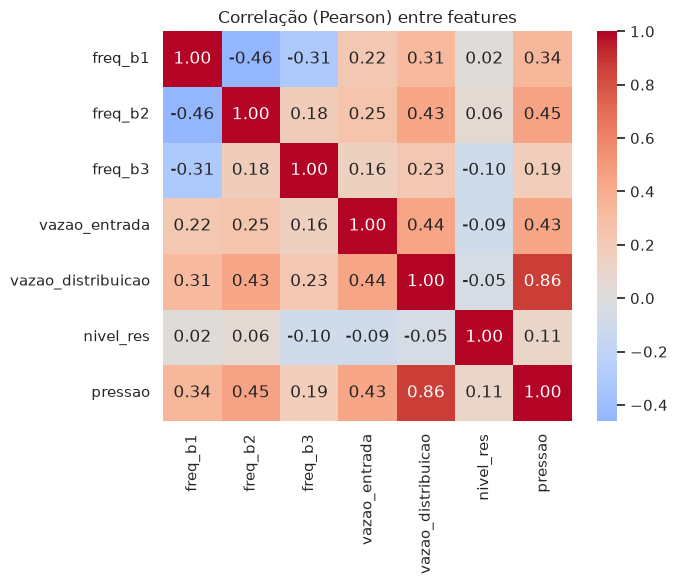

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    mimo.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax
)
ax.set_title("Correlação (Pearson) entre features")
fig.tight_layout()

Text(0.5, 1.02, 'Pairplot das features')

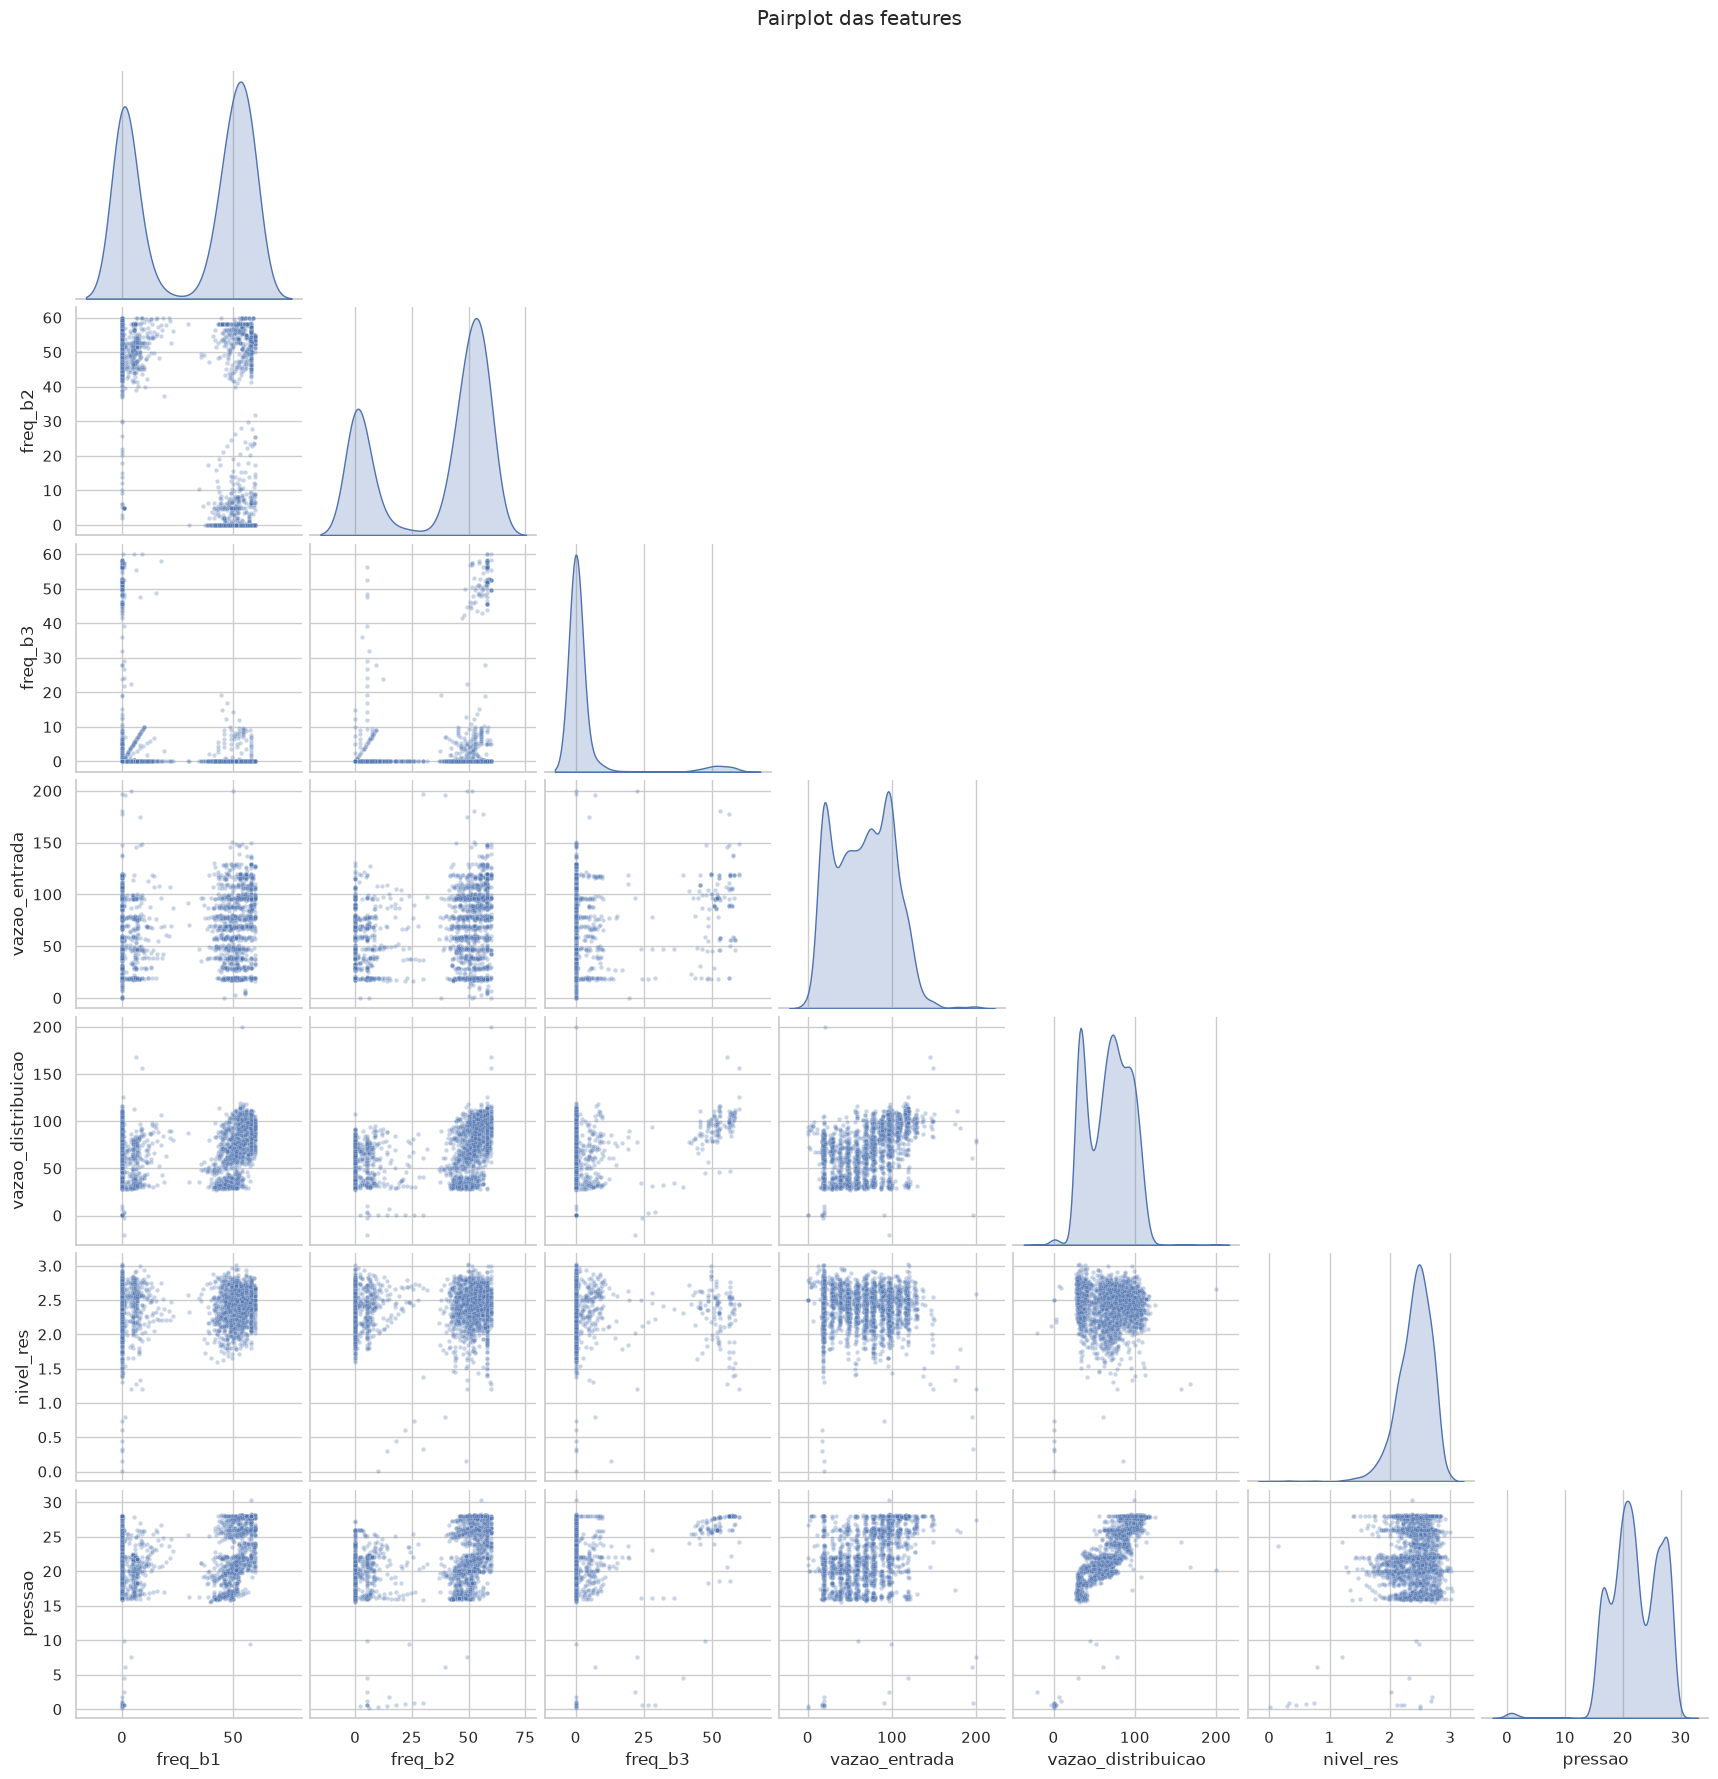

In [6]:
sns.pairplot(mimo[FEATURE_COLS], diag_kind="kde", corner=True, plot_kws={"alpha": 0.3, "s": 10})
plt.suptitle("Pairplot das features", y=1.02)

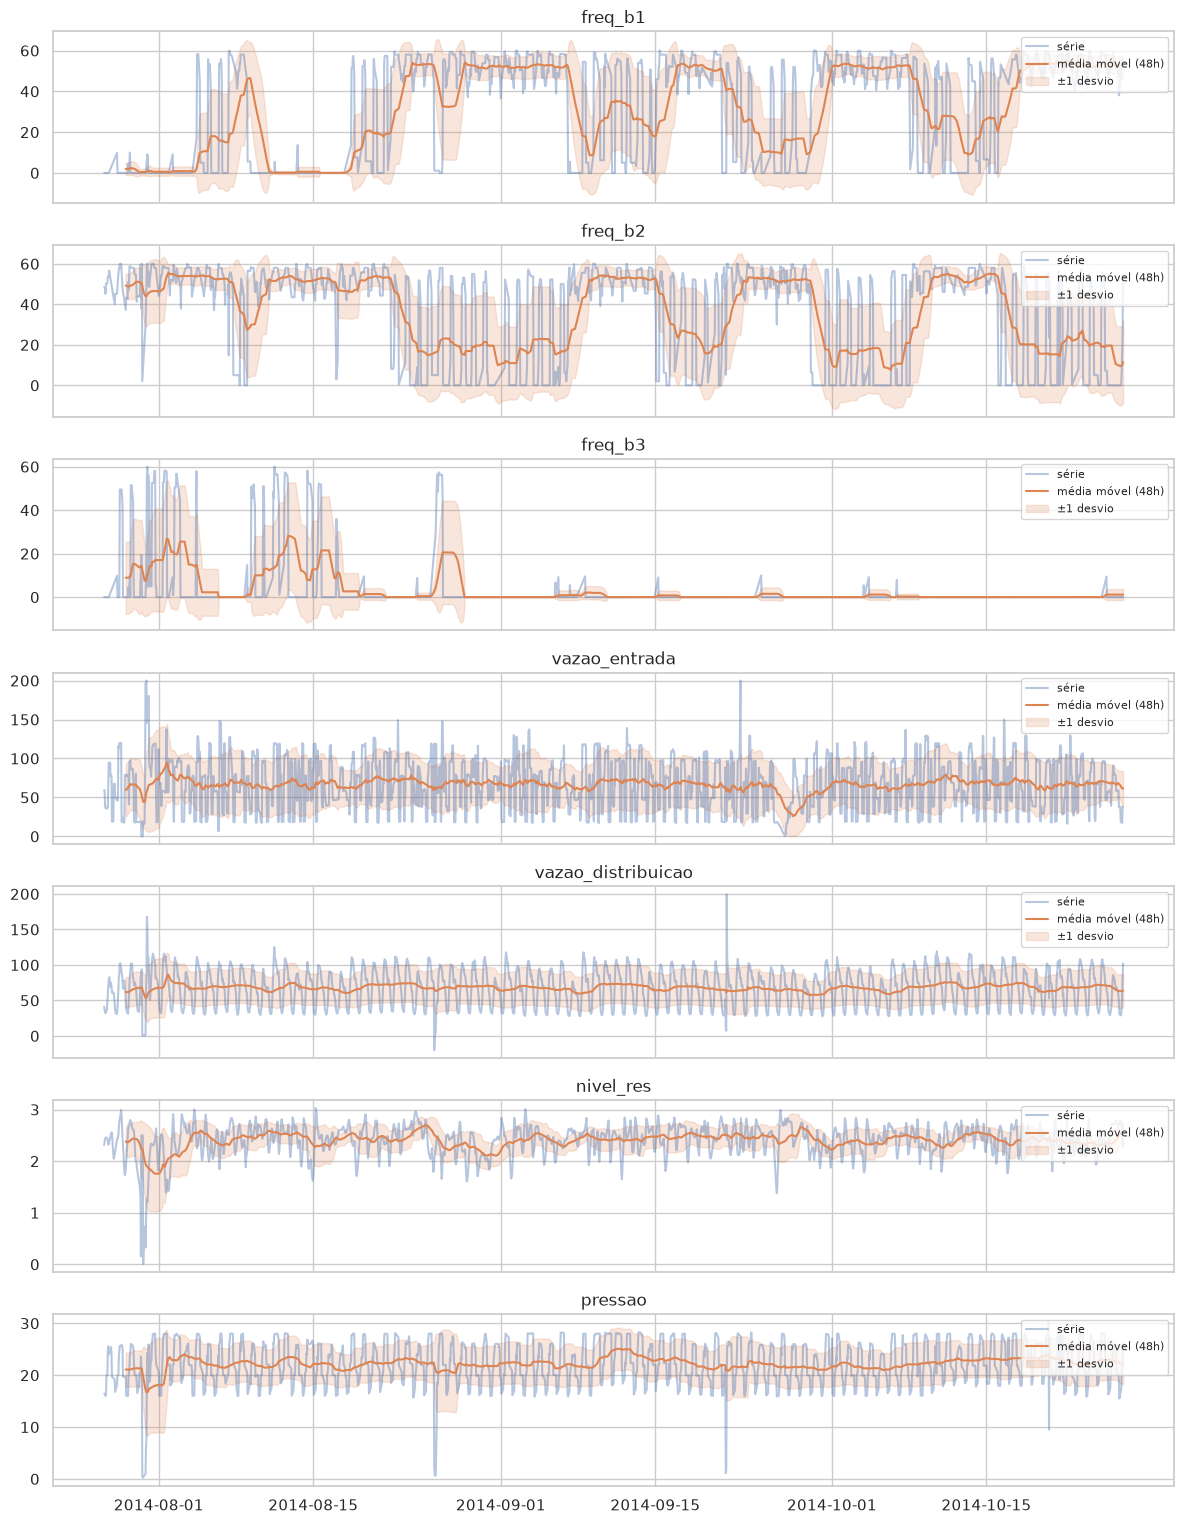

In [7]:
ROLL_WINDOW = 48
rolling_mean = mimo.rolling(ROLL_WINDOW).mean()
rolling_std = mimo.rolling(ROLL_WINDOW).std()

fig, axs = plt.subplots(len(FEATURE_COLS), 1, figsize=(12, 2.2 * len(FEATURE_COLS)), sharex=True)
for i, col in enumerate(FEATURE_COLS):
    axs[i].plot(mimo.index, mimo[col], alpha=0.4, label="série")
    axs[i].plot(rolling_mean.index, rolling_mean[col], color="C1", label=f"média móvel ({ROLL_WINDOW}h)")
    axs[i].fill_between(
        rolling_mean.index,
        rolling_mean[col] - rolling_std[col],
        rolling_mean[col] + rolling_std[col],
        color="C1",
        alpha=0.2,
        label="±1 desvio",
    )
    axs[i].set_title(col)
    axs[i].legend(loc="upper right", fontsize=8)
fig.tight_layout()

#### Tendência e decomposição

Decomposição por EWT (via `TimeSeriesPreprocessor`) e decomposição clássica STL, para comparar.

In [8]:
pp = TimeSeriesPreprocessor(
    apply_ewt=True,
    detrend=True,
    apply_filter=True,
    normalize=False,
    differencing=False,
    remove_outliers=True,
)
pp._plot_comparison = lambda *args, **kwargs: None  # suppress internal diagnostic plots
raw = mimo.to_numpy()
_, _, processed = pp.fit_transform(raw)
trend = pp.get_trend_component()

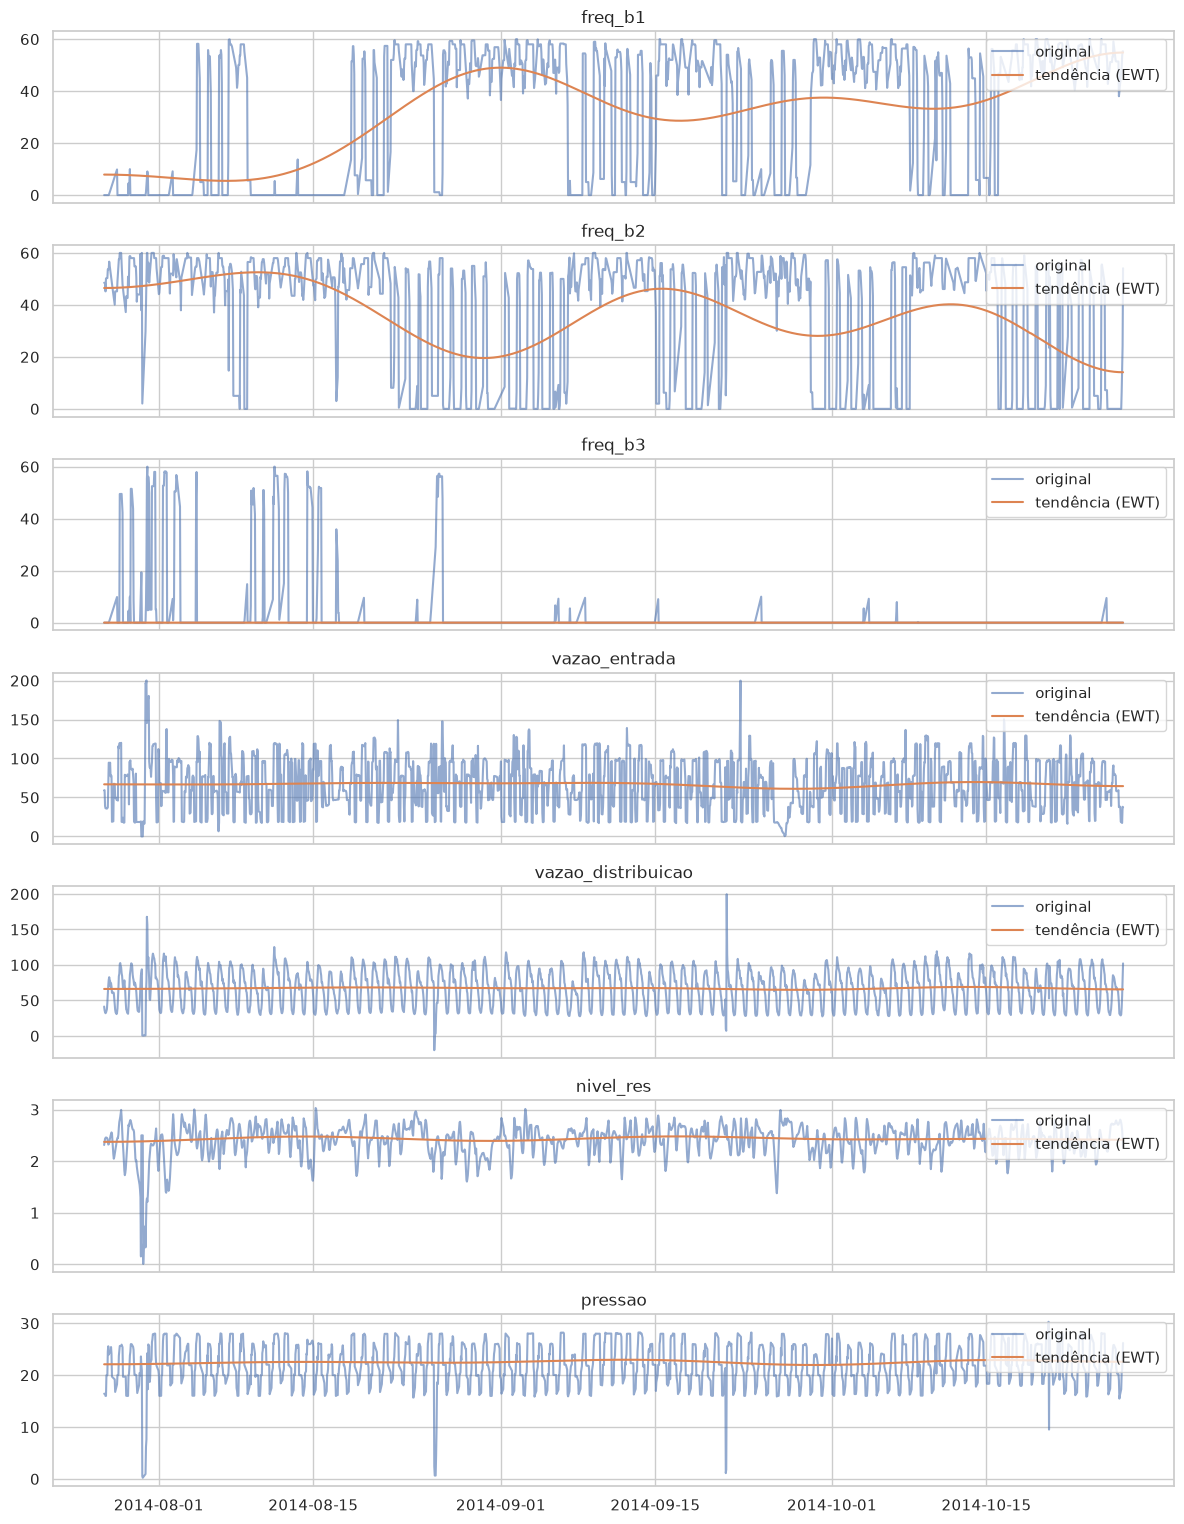

In [9]:
fig, axs = plt.subplots(len(FEATURE_COLS), 1, figsize=(12, 2.2 * len(FEATURE_COLS)), sharex=True)
for i, col in enumerate(FEATURE_COLS):
    axs[i].plot(mimo.index, raw[:, i], label="original", alpha=0.6)
    axs[i].plot(mimo.index, trend[:, i], label="tendência (EWT)", color="C1")
    axs[i].set_title(col)
    axs[i].legend(loc="upper right")
fig.tight_layout()

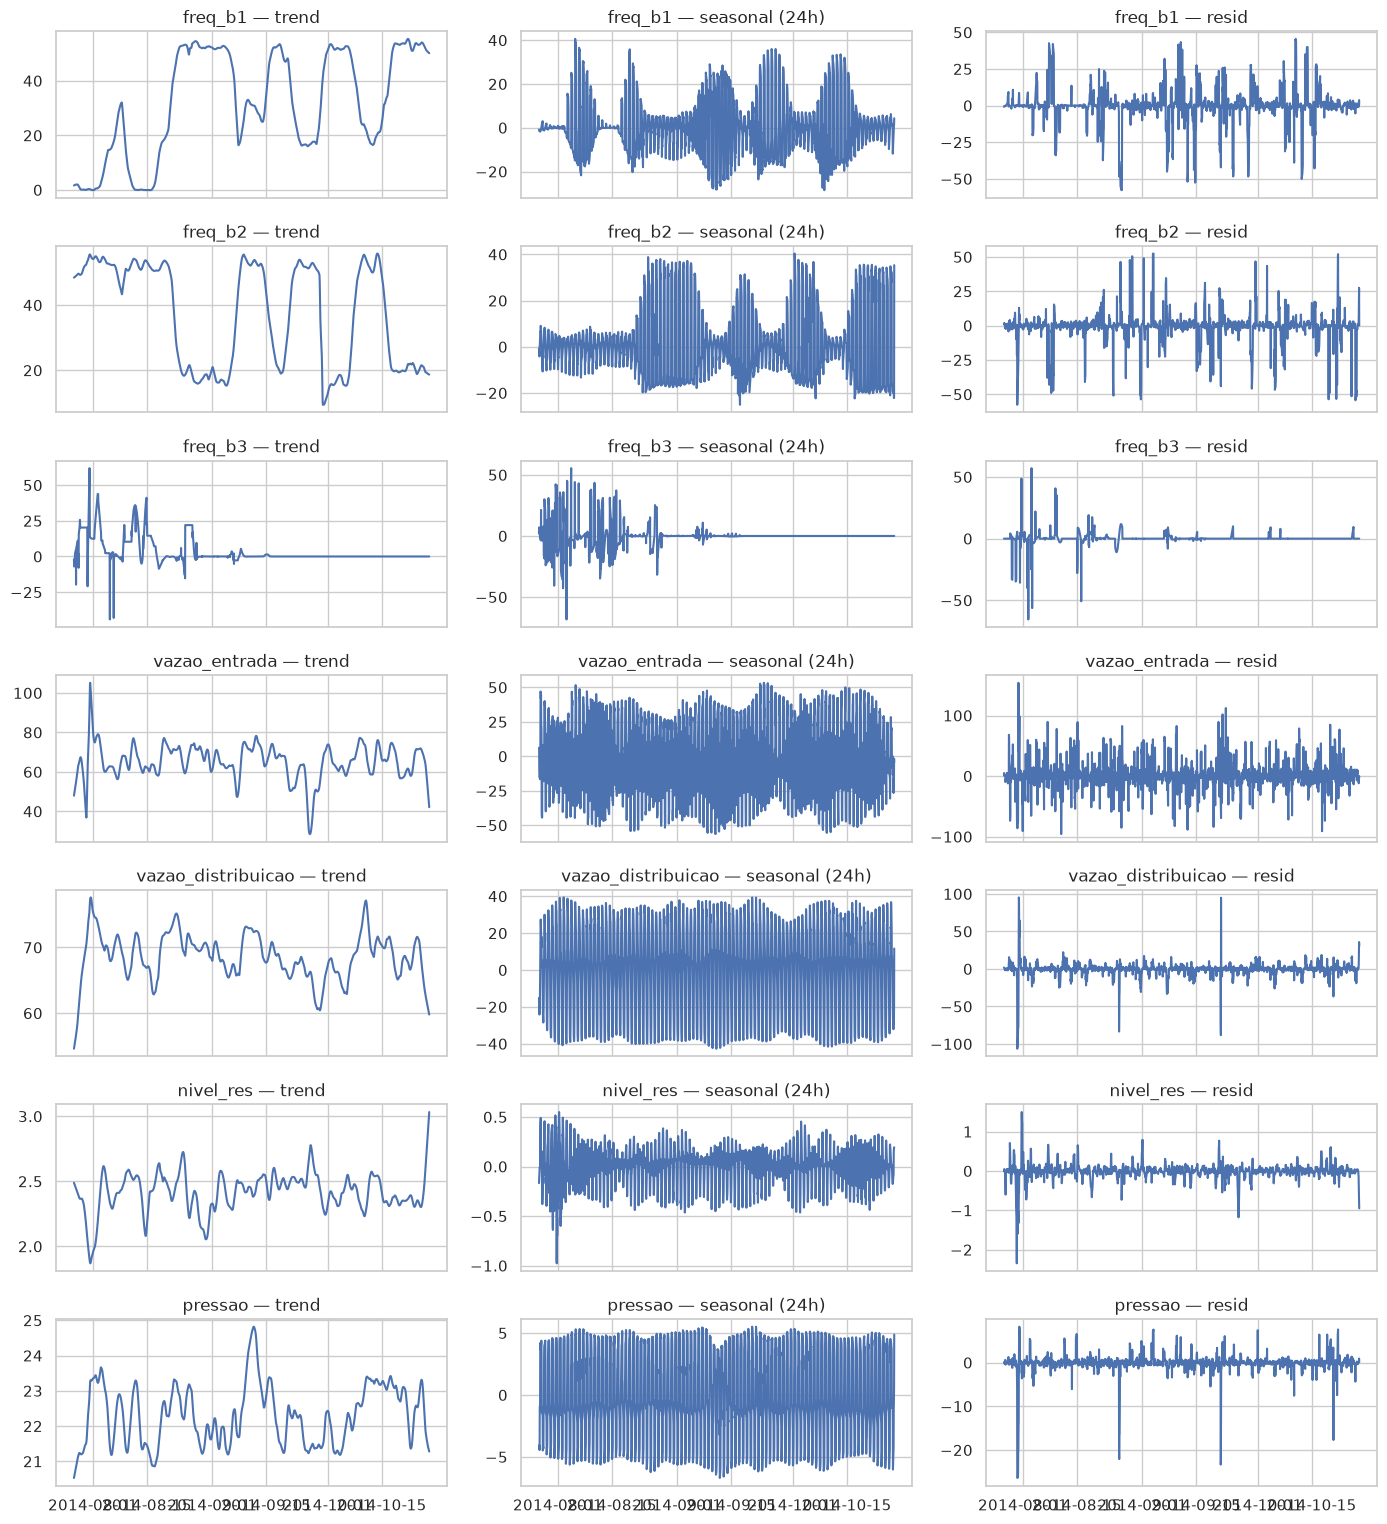

In [10]:
stl_results = {
    col: STL(mimo[col], period=24, robust=True).fit() for col in FEATURE_COLS
}

fig, axs = plt.subplots(len(FEATURE_COLS), 3, figsize=(14, 2.2 * len(FEATURE_COLS)), sharex=True)
for i, col in enumerate(FEATURE_COLS):
    res = stl_results[col]
    axs[i, 0].plot(res.trend)
    axs[i, 0].set_title(f"{col} — trend")
    axs[i, 1].plot(res.seasonal)
    axs[i, 1].set_title(f"{col} — seasonal (24h)")
    axs[i, 2].plot(res.resid)
    axs[i, 2].set_title(f"{col} — resid")
fig.tight_layout()

#### Estacionariedade (ADF)

Teste de Dickey-Fuller aumentado na série original e na série detrended (resíduo pós-EWT).

In [11]:
detrended = raw - trend

adf_rows = []
for i, col in enumerate(FEATURE_COLS):
    stat_orig, p_orig, *_ = adfuller(raw[:, i], autolag="AIC")
    stat_det, p_det, *_ = adfuller(detrended[:, i], autolag="AIC")
    adf_rows.append(
        {
            "feature": col,
            "adf_stat_original": stat_orig,
            "p_value_original": p_orig,
            "adf_stat_detrended": stat_det,
            "p_value_detrended": p_det,
        }
    )

adf_df = pd.DataFrame(adf_rows).set_index("feature")
adf_df

/tmp/ipykernel_13682/3297419509.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat_orig, p_orig, *_ = adfuller(raw[:, i], autolag="AIC")
/tmp/ipykernel_13682/3297419509.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat_det, p_det, *_ = adfuller(detrended[:, i], autolag="AIC")
/tmp/ipykernel_13682/3297419509.py:5: FutureWarning: adfuller currently returns a pl

/tmp/ipykernel_13682/3297419509.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat_det, p_det, *_ = adfuller(detrended[:, i], autolag="AIC")
/tmp/ipykernel_13682/3297419509.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat_orig, p_orig, *_ = adfuller(raw[:, i], autolag="AIC")
/tmp/ipykernel_13682/3297419509.py:6: FutureWarning: adfuller currently returns a pl

,adf_stat_original,p_value_original,adf_stat_detrended,p_value_detrended
feature,,,,
freq_b1,-3.693931,4.199338e-03,-5.168888,1.017330e-05
freq_b2,-3.211800,1.931172e-02,-4.298811,4.463238e-04
freq_b3,-5.930323,2.389131e-07,-5.930323,2.389131e-07
vazao_entrada,-7.871426,4.973166e-12,-8.491822,1.307221e-13
vazao_distribuicao,-8.190925,7.671919e-13,-8.533333,1.023607e-13
nivel_res,-7.619534,2.146756e-11,-8.071206,1.547820e-12
pressao,-7.139436,3.354019e-10,-8.034974,1.913498e-12


#### Autocorrelação (ACF/PACF)

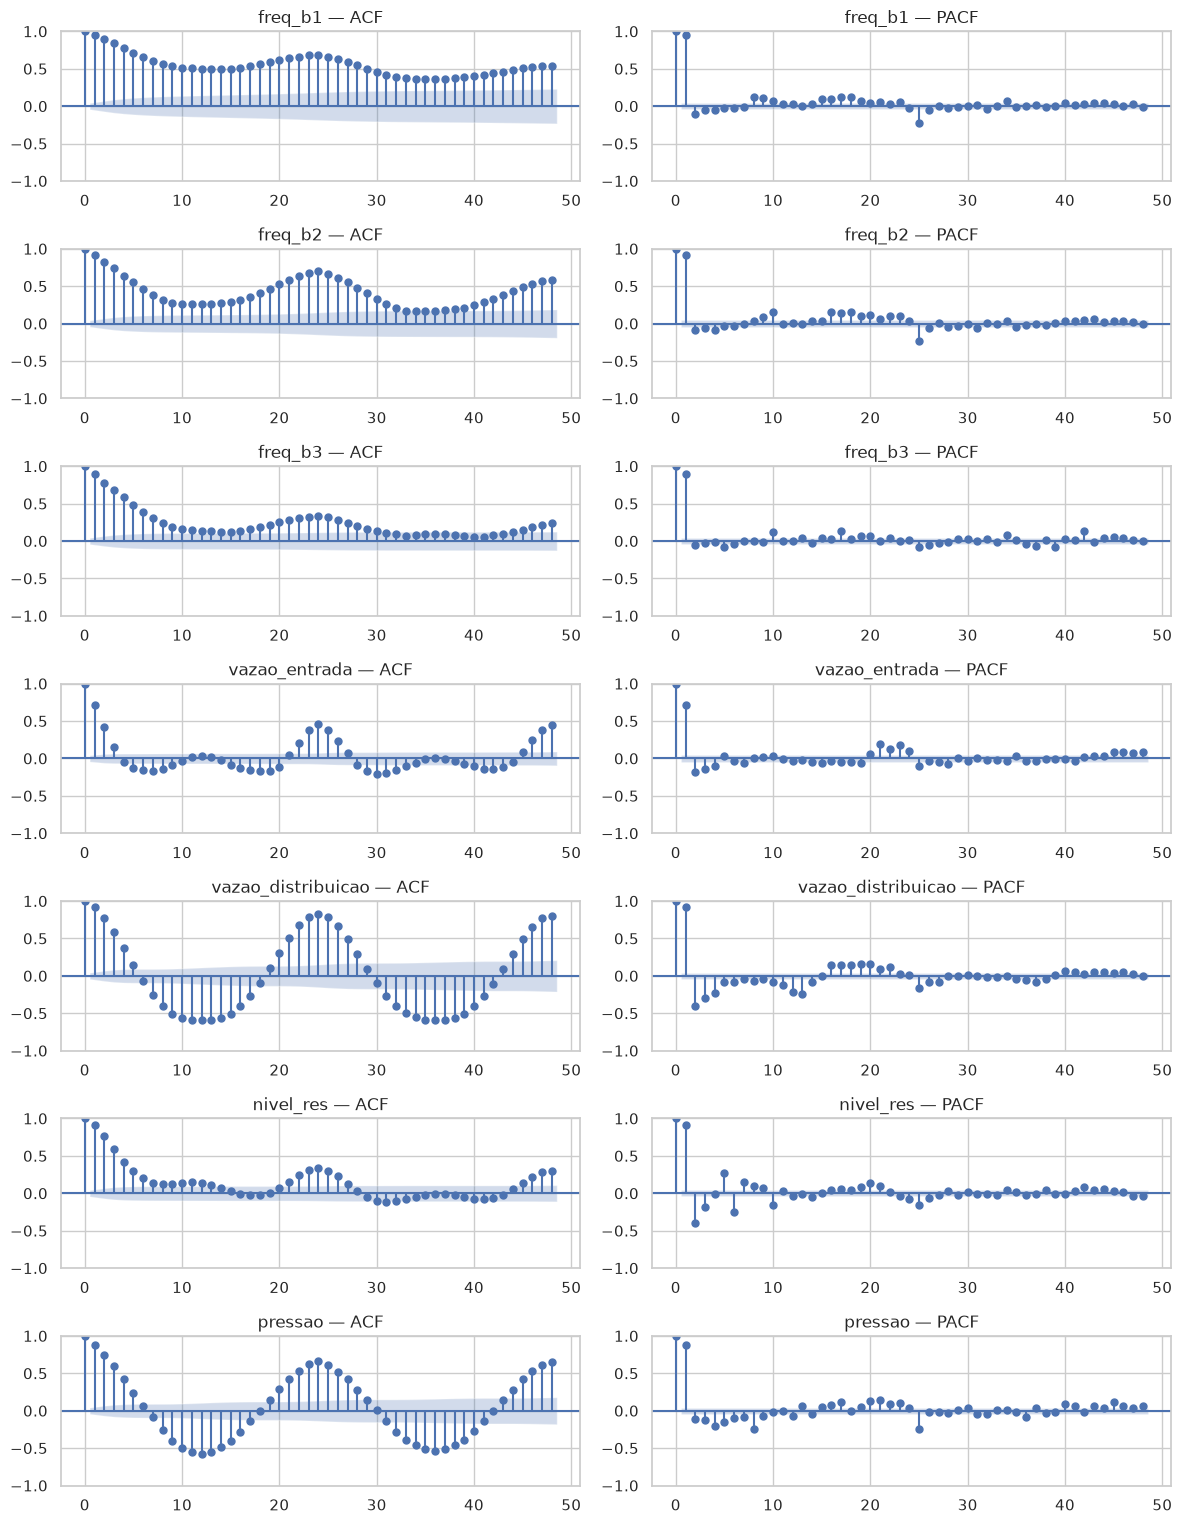

In [12]:
fig, axs = plt.subplots(len(FEATURE_COLS), 2, figsize=(12, 2.2 * len(FEATURE_COLS)))
for i, col in enumerate(FEATURE_COLS):
    plot_acf(raw[:, i], lags=48, ax=axs[i, 0], title=f"{col} — ACF")
    plot_pacf(raw[:, i], lags=48, ax=axs[i, 1], method="ywm", title=f"{col} — PACF")
fig.tight_layout()

#### Causalidade de Granger

Testado par a par entre as entradas (`INPUT_COLS`) e saídas (`OUTPUT_COLS`), nas séries detrended.

In [13]:
MAX_LAG = 12

granger_rows = []
detrended_df = pd.DataFrame(detrended, columns=FEATURE_COLS, index=mimo.index)

for src in INPUT_COLS:
    for dst in OUTPUT_COLS:
        pair = detrended_df[[dst, src]].to_numpy()
        res = grangercausalitytests(pair, maxlag=MAX_LAG)
        best_lag = min(
            res, key=lambda lag: res[lag][0]["ssr_ftest"][1]
        )
        p_value = res[best_lag][0]["ssr_ftest"][1]
        granger_rows.append(
            {"causa": src, "efeito": dst, "melhor_lag": best_lag, "p_value": p_value}
        )

granger_df = pd.DataFrame(granger_rows).sort_values("p_value")
granger_df

,causa,efeito,melhor_lag,p_value
10,vazao_entrada,nivel_res,1,4.963150e-124
9,vazao_entrada,vazao_distribuicao,8,6.778777e-34
3,freq_b2,vazao_distribuicao,8,1.359482e-21
11,vazao_entrada,pressao,9,3.481073e-14
4,freq_b2,nivel_res,12,8.013280e-14
0,freq_b1,vazao_distribuicao,9,1.516205e-09
2,freq_b1,pressao,2,6.218234e-08
5,freq_b2,pressao,11,3.317536e-06
6,freq_b3,vazao_distribuicao,9,7.806830e-05
1,freq_b1,nivel_res,12,1.002362e-03


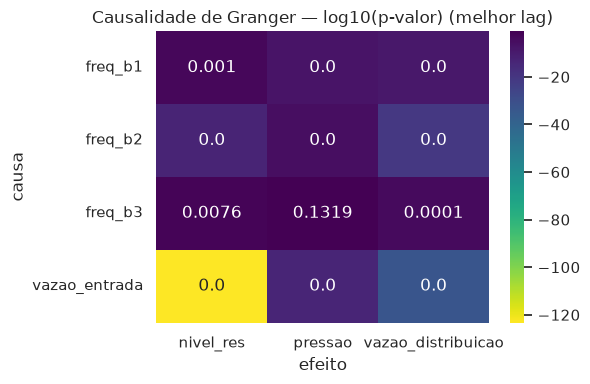

In [14]:
pivot = granger_df.pivot(index="causa", columns="efeito", values="p_value")
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    np.log10(pivot.astype(float)),
    annot=pivot.round(4),
    fmt="",
    cmap="viridis_r",
    ax=ax,
)
ax.set_title("Causalidade de Granger — log10(p-valor) (melhor lag)")
fig.tight_layout()

#### Cointegração

Engle-Granger par a par (todas as 7 features) e Johansen no conjunto completo.

In [15]:
coint_rows = []
for i, a in enumerate(FEATURE_COLS):
    for b in FEATURE_COLS[i + 1 :]:
        stat, p_value, _ = coint(mimo[a], mimo[b])
        coint_rows.append({"par": f"{a} / {b}", "coint_stat": stat, "p_value": p_value})

coint_df = pd.DataFrame(coint_rows).sort_values("p_value")
coint_df

,par,coint_stat,p_value
15,vazao_entrada / vazao_distribuicao,-9.023370,7.585816e-14
17,vazao_entrada / pressao,-8.784760,3.087890e-13
18,vazao_distribuicao / nivel_res,-8.366549,3.586201e-12
16,vazao_entrada / nivel_res,-8.051627,2.241299e-11
20,nivel_res / pressao,-7.579453,3.370083e-10
19,vazao_distribuicao / pressao,-6.872049,1.724656e-08
13,freq_b3 / nivel_res,-6.062239,1.190284e-06
11,freq_b3 / vazao_entrada,-5.961851,1.961360e-06
12,freq_b3 / vazao_distribuicao,-5.846656,3.451823e-06
14,freq_b3 / pressao,-5.845641,3.468920e-06


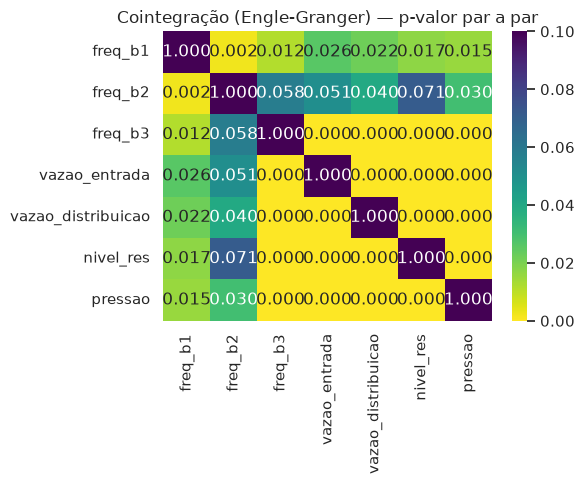

In [16]:
coint_matrix = pd.DataFrame(
    np.ones((len(FEATURE_COLS), len(FEATURE_COLS))),
    index=FEATURE_COLS,
    columns=FEATURE_COLS,
)
for i, a in enumerate(FEATURE_COLS):
    for b in FEATURE_COLS[i + 1 :]:
        p = coint_df.loc[coint_df["par"] == f"{a} / {b}", "p_value"].iloc[0]
        coint_matrix.loc[a, b] = p
        coint_matrix.loc[b, a] = p

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(coint_matrix, annot=True, fmt=".3f", cmap="viridis_r", vmax=0.1, ax=ax)
ax.set_title("Cointegração (Engle-Granger) — p-valor par a par")
fig.tight_layout()

In [17]:
johansen = coint_johansen(mimo.to_numpy(), det_order=0, k_ar_diff=1)

johansen_df = pd.DataFrame(
    {
        "trace_stat": johansen.lr1,
        "crit_90%": johansen.cvt[:, 0],
        "crit_95%": johansen.cvt[:, 1],
        "crit_99%": johansen.cvt[:, 2],
    }
)
johansen_df

/home/rwp/code/mimo_sys/.venv/lib/python3.12/site-packages/statsmodels/tsa/vector_ar/vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
/home/rwp/code/mimo_sys/.venv/lib/python3.12/site-packages/statsmodels/tsa/vector_ar/vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


,trace_stat,crit_90%,crit_95%,crit_99%
0,2515.261471,120.3673,125.6185,135.9825
1,1405.777825,91.1090,95.7542,104.9637
2,981.033454,65.8202,69.8189,77.8202
3,619.304573,44.4929,47.8545,54.6815
4,390.961389,27.0669,29.7961,35.4628
5,196.214799,13.4294,15.4943,19.9349
6,49.489202,2.7055,3.8415,6.6349


#### DTW e clustering de séries temporais

Matriz de distância DTW entre as 7 features (normalizadas) e clustering hierárquico sobre essa matriz.

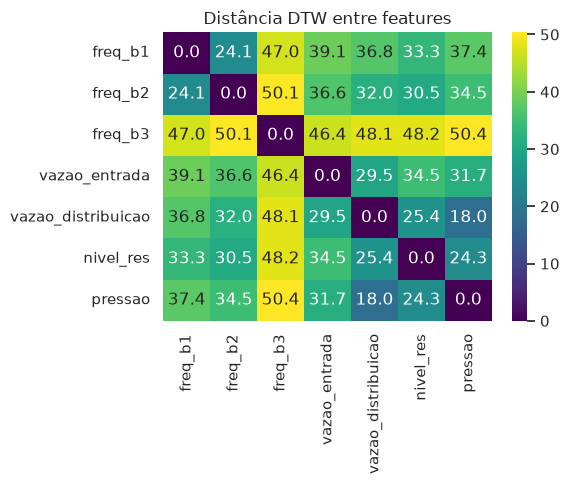

In [18]:
scaled = (raw - raw.mean(axis=0)) / raw.std(axis=0)
series_list = [scaled[:, i].astype(np.double) for i in range(scaled.shape[1])]
dist_matrix = dtw.distance_matrix_fast(series_list)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    dist_matrix,
    xticklabels=FEATURE_COLS,
    yticklabels=FEATURE_COLS,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    ax=ax,
)
ax.set_title("Distância DTW entre features")
fig.tight_layout()

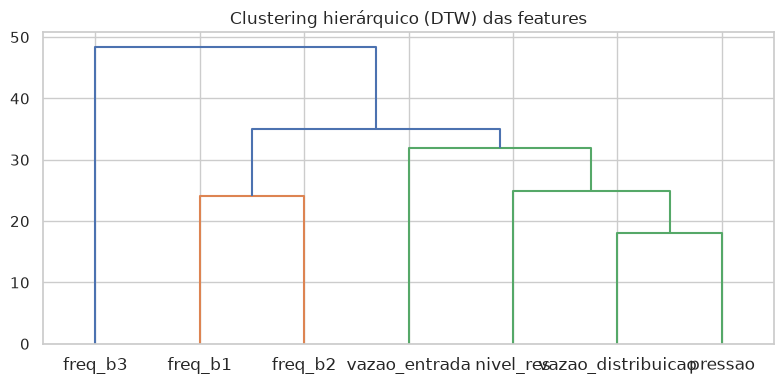

In [19]:
condensed = squareform(dist_matrix, checks=False)
linkage = hierarchy.linkage(condensed, method="average")

fig, ax = plt.subplots(figsize=(8, 4))
hierarchy.dendrogram(linkage, labels=FEATURE_COLS, ax=ax)
ax.set_title("Clustering hierárquico (DTW) das features")
fig.tight_layout()

#### Shapelets (implementação simples)

Sem dependência extra: busca, por feature, das janelas de tamanho fixo com
maior variância interna (candidatas a padrões discriminativos/recorrentes),
e ranking das mais distintas entre si por distância euclidiana.

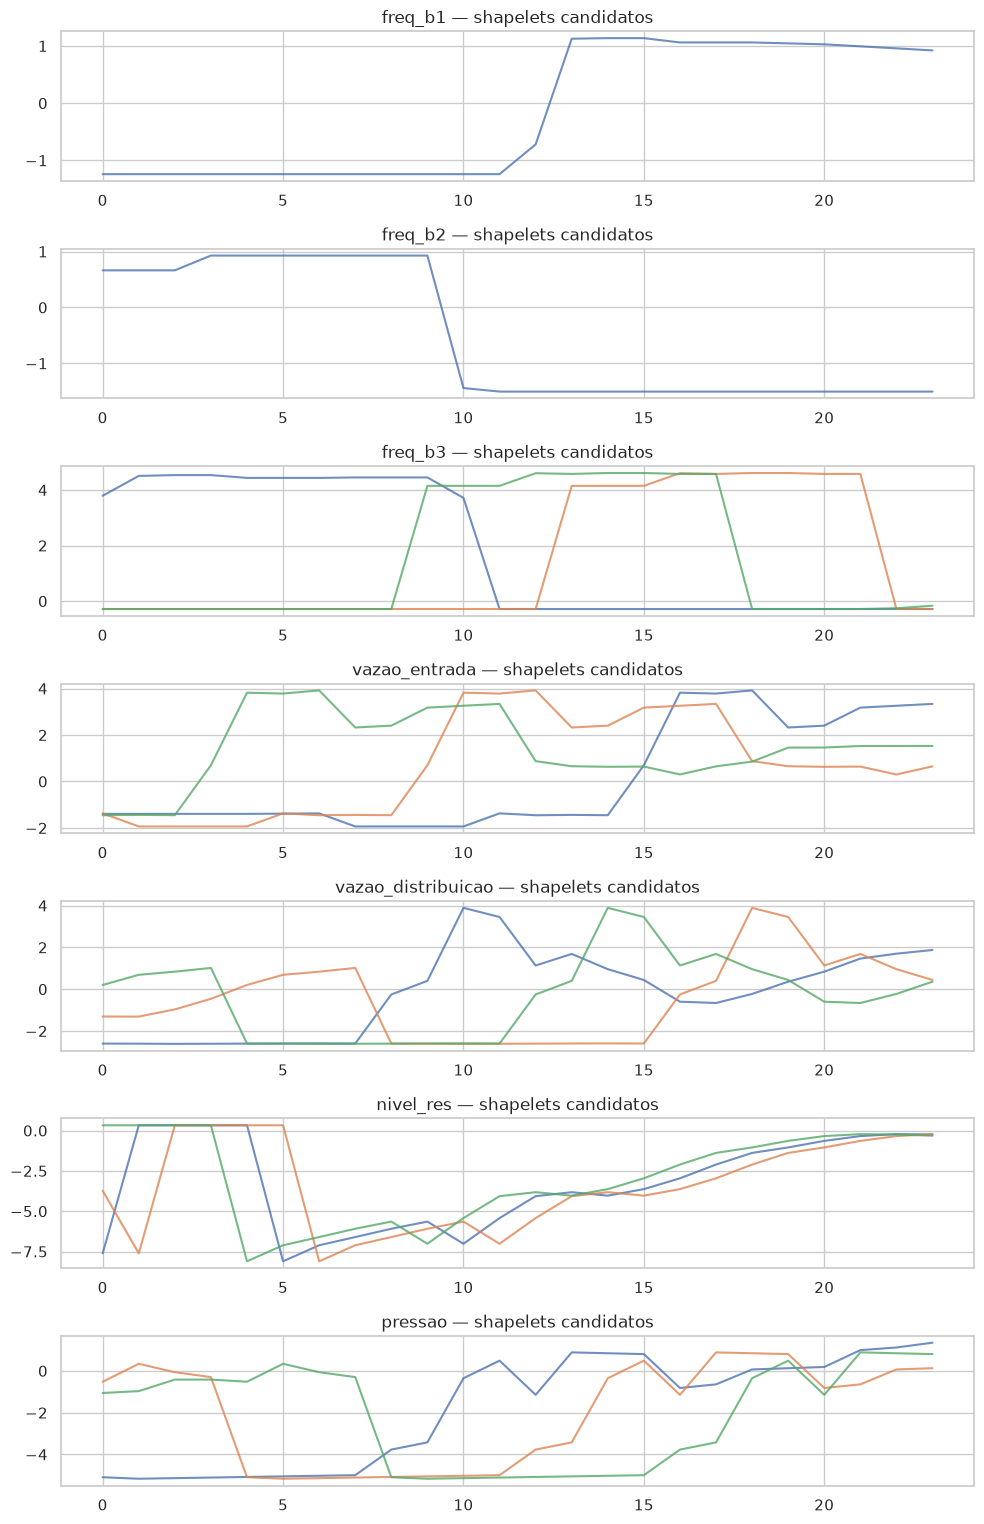

In [20]:
def extract_candidate_shapelets(
    series: np.ndarray, window: int = 24, top_k: int = 3
) -> np.ndarray:
    """Top-`top_k` most-distinct high-variance windows of `series`."""
    n_windows = len(series) - window + 1
    windows = np.stack([series[i : i + window] for i in range(n_windows)])
    variances = windows.var(axis=1)
    order = np.argsort(variances)[::-1]

    selected = [order[0]]
    for idx in order[1:]:
        if len(selected) >= top_k:
            break
        candidate = windows[idx]
        if all(
            np.linalg.norm(candidate - windows[s]) > window * 0.5
            for s in selected
        ):
            selected.append(idx)
    return windows[selected]


fig, axs = plt.subplots(len(FEATURE_COLS), 1, figsize=(10, 2.2 * len(FEATURE_COLS)))
for i, col in enumerate(FEATURE_COLS):
    shapelets = extract_candidate_shapelets(scaled[:, i])
    for s in shapelets:
        axs[i].plot(s, alpha=0.8)
    axs[i].set_title(f"{col} — shapelets candidatos")
fig.tight_layout()

#### Domínio da frequência (sinais/controle)

Periodograma, PSD via Welch e espectrograma por feature; densidade espectral
cruzada e coerência entre pares entrada/saída.

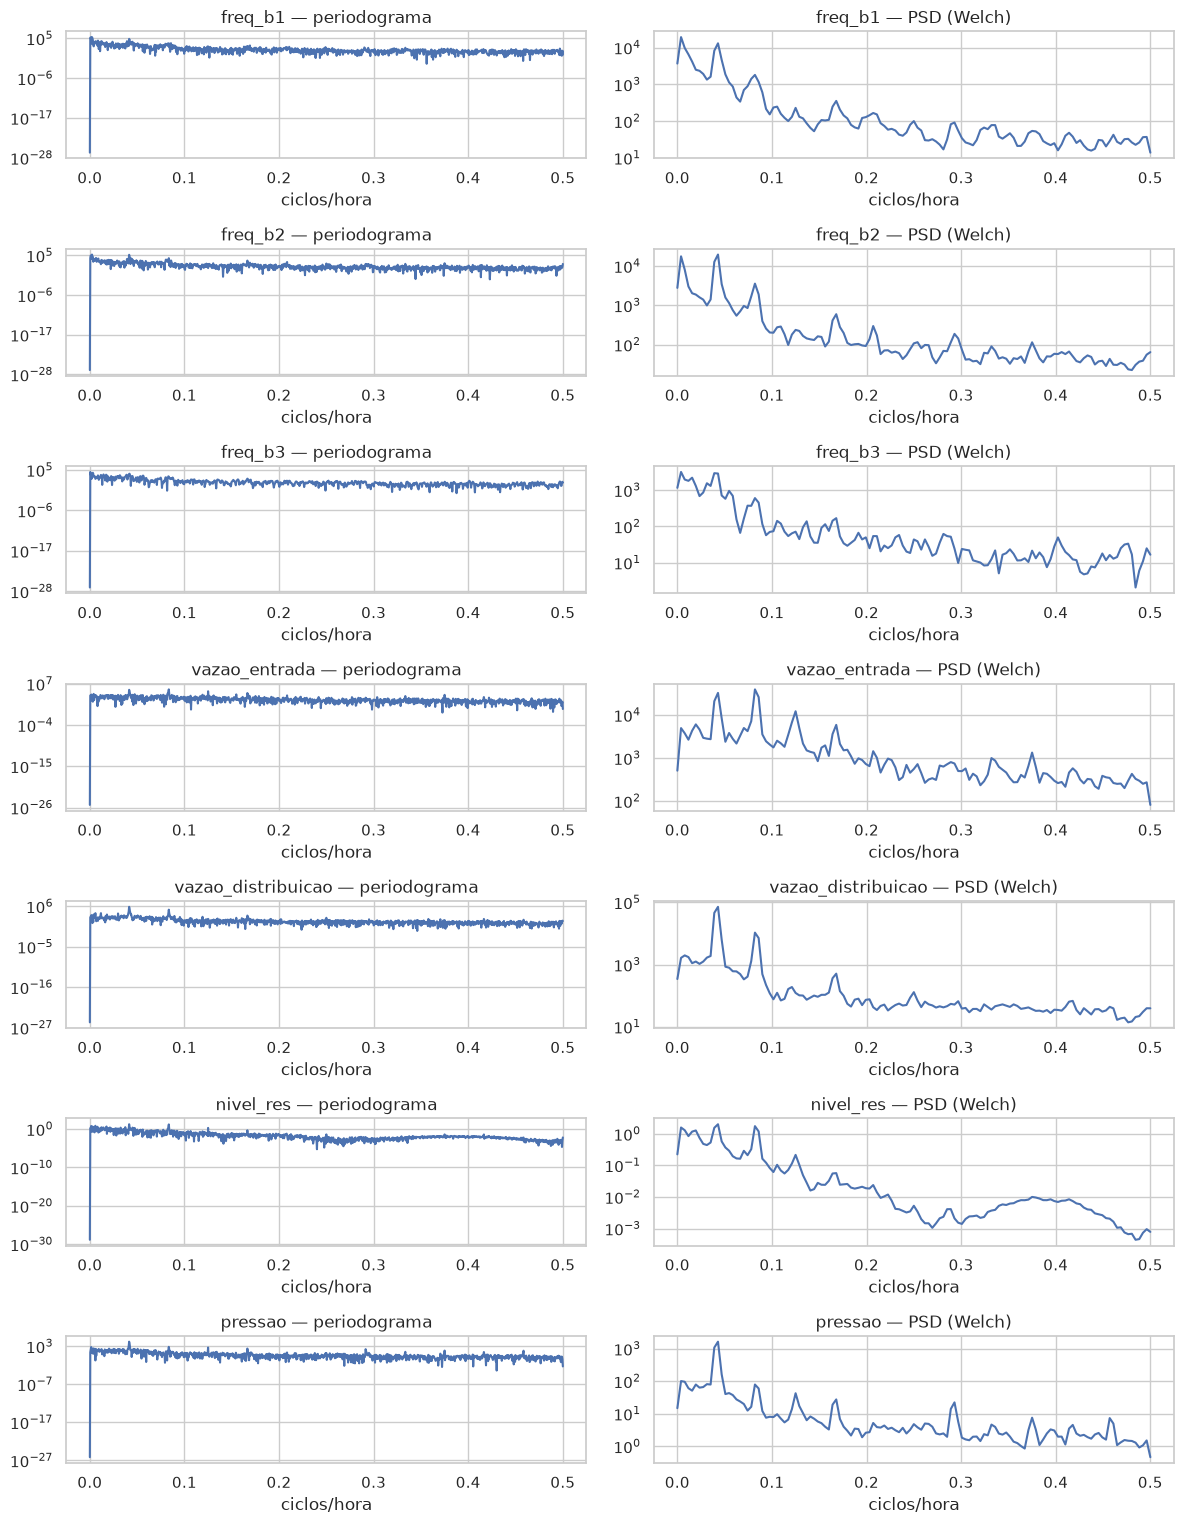

In [21]:
FS = 1.0  # 1 amostra/hora

fig, axs = plt.subplots(len(FEATURE_COLS), 2, figsize=(12, 2.2 * len(FEATURE_COLS)))
for i, col in enumerate(FEATURE_COLS):
    f_p, pxx_p = signal.periodogram(raw[:, i], fs=FS)
    axs[i, 0].semilogy(f_p, pxx_p)
    axs[i, 0].set_title(f"{col} — periodograma")
    axs[i, 0].set_xlabel("ciclos/hora")

    f_w, pxx_w = signal.welch(raw[:, i], fs=FS, nperseg=256)
    axs[i, 1].semilogy(f_w, pxx_w)
    axs[i, 1].set_title(f"{col} — PSD (Welch)")
    axs[i, 1].set_xlabel("ciclos/hora")
fig.tight_layout()

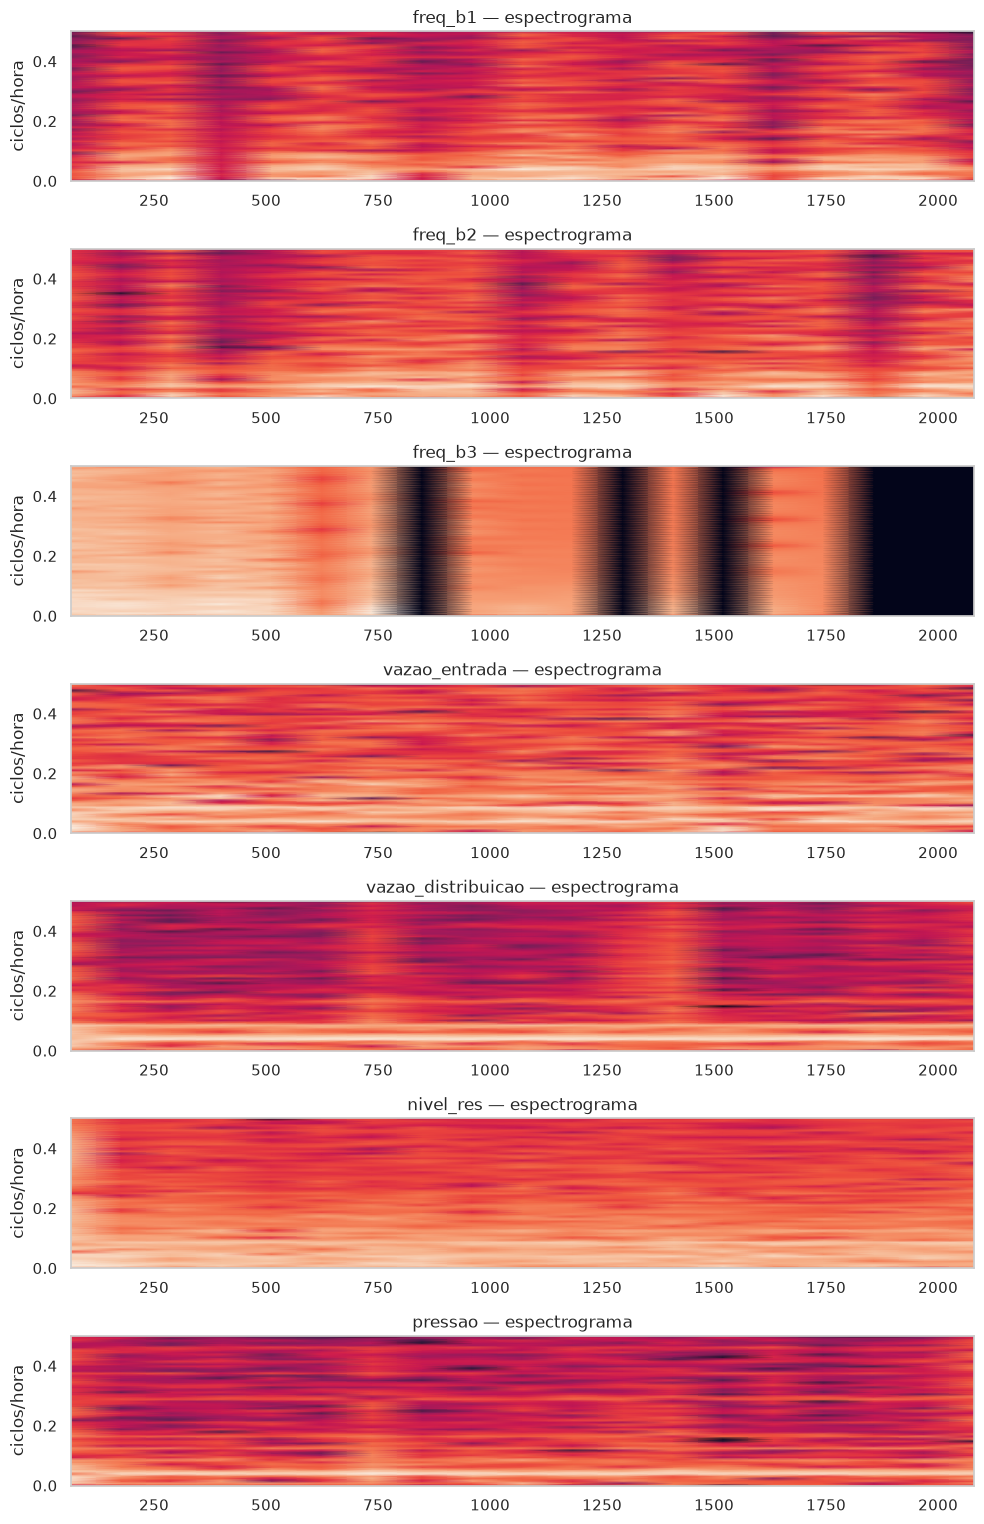

In [22]:
fig, axs = plt.subplots(len(FEATURE_COLS), 1, figsize=(10, 2.2 * len(FEATURE_COLS)))
for i, col in enumerate(FEATURE_COLS):
    f_s, t_s, sxx = signal.spectrogram(raw[:, i], fs=FS, nperseg=128)
    axs[i].pcolormesh(t_s, f_s, 10 * np.log10(sxx + 1e-12), shading="gouraud")
    axs[i].set_title(f"{col} — espectrograma")
    axs[i].set_ylabel("ciclos/hora")
fig.tight_layout()

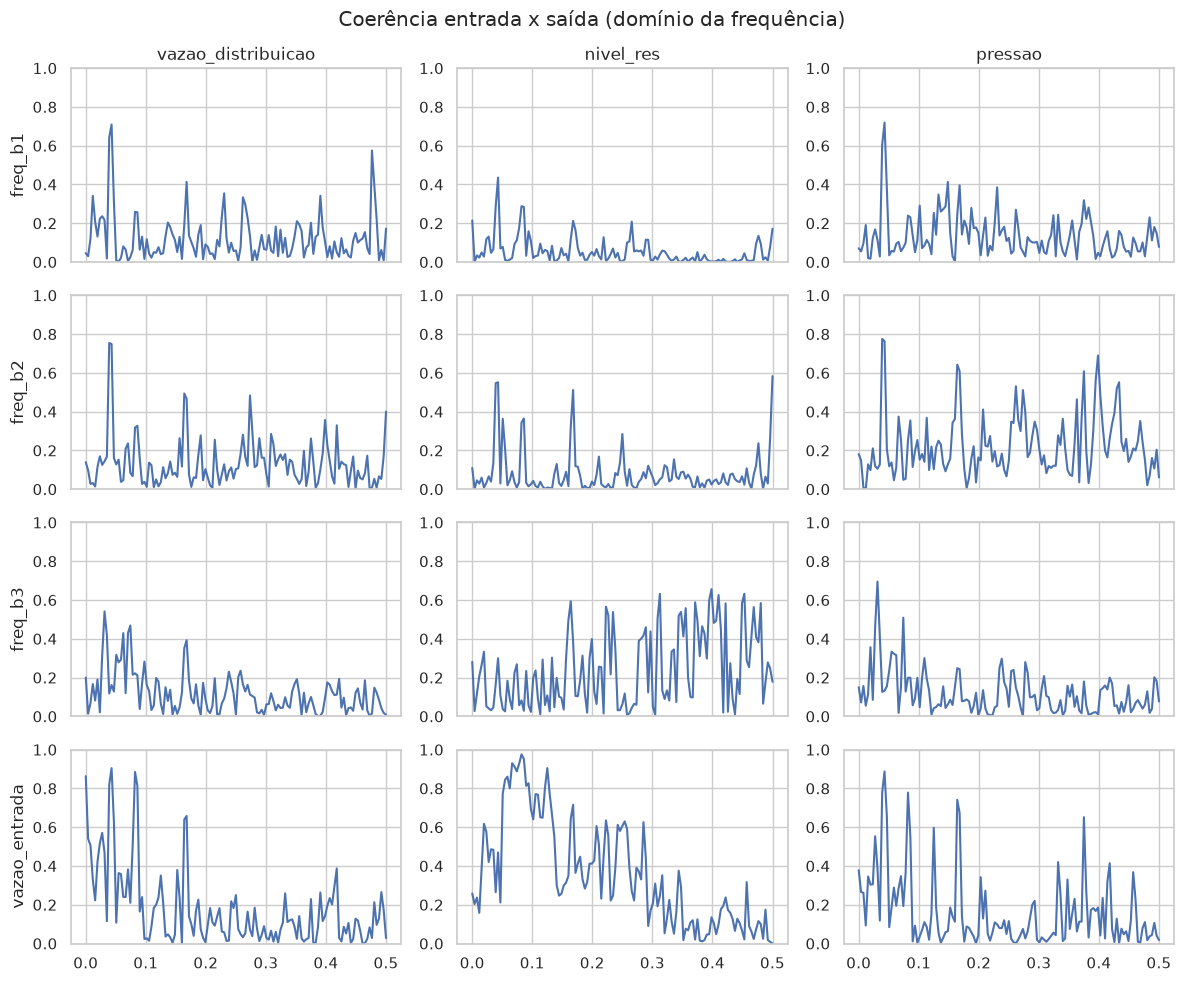

In [23]:
fig, axs = plt.subplots(len(INPUT_COLS), len(OUTPUT_COLS), figsize=(12, 10), sharex=True)
for i, u in enumerate(INPUT_COLS):
    for j, y in enumerate(OUTPUT_COLS):
        f_c, cxy = signal.coherence(
            mimo[u].to_numpy(), mimo[y].to_numpy(), fs=FS, nperseg=256
        )
        axs[i, j].plot(f_c, cxy)
        axs[i, j].set_ylim(0, 1)
        if i == 0:
            axs[i, j].set_title(y)
        if j == 0:
            axs[i, j].set_ylabel(u)
fig.suptitle("Coerência entrada x saída (domínio da frequência)")
fig.tight_layout()

#### Identificação de sistemas (ARX simples, estilo Guidorzi)

Resposta ao impulso empírica via correlação cruzada normalizada, e um modelo
ARX de ordem fixa por par entrada→saída (regressão linear nos lags),
reportando erro de predição um passo à frente e os polos do modelo.

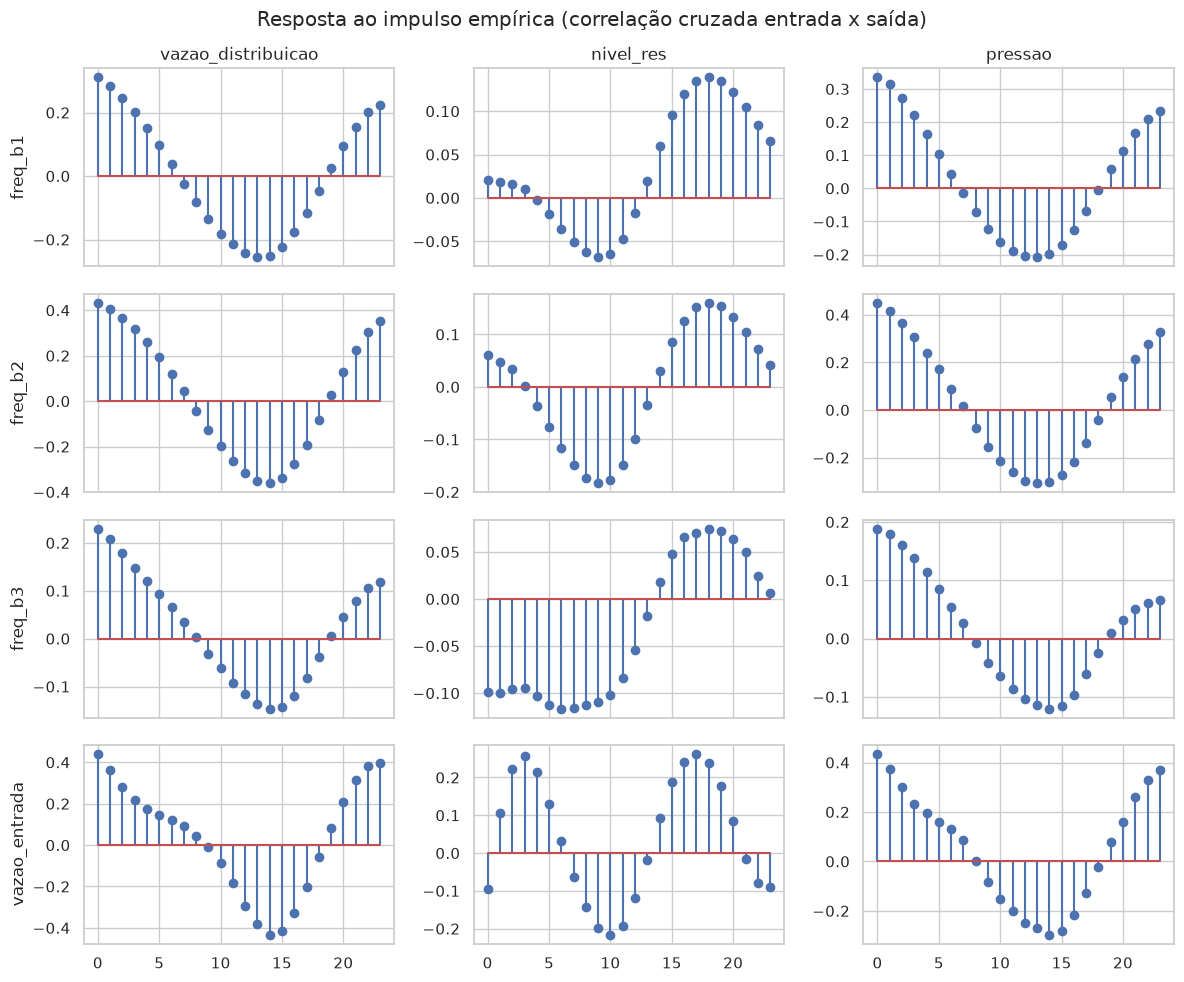

In [24]:
def impulse_response_estimate(u: np.ndarray, y: np.ndarray, max_lag: int = 24) -> np.ndarray:
    """Normalized cross-correlation of `u` and `y` as an empirical IRF."""
    u_c = (u - u.mean()) / u.std()
    y_c = (y - y.mean()) / y.std()
    corr = signal.correlate(y_c, u_c, mode="full") / len(u_c)
    mid = len(corr) // 2
    return corr[mid : mid + max_lag]


fig, axs = plt.subplots(len(INPUT_COLS), len(OUTPUT_COLS), figsize=(12, 10), sharex=True)
for i, u in enumerate(INPUT_COLS):
    for j, y in enumerate(OUTPUT_COLS):
        irf = impulse_response_estimate(mimo[u].to_numpy(), mimo[y].to_numpy())
        axs[i, j].stem(irf)
        if i == 0:
            axs[i, j].set_title(y)
        if j == 0:
            axs[i, j].set_ylabel(u)
fig.suptitle("Resposta ao impulso empírica (correlação cruzada entrada x saída)")
fig.tight_layout()

In [25]:
def fit_arx(
    u: np.ndarray, y: np.ndarray, na: int = 2, nb: int = 2
) -> tuple[np.ndarray, np.ndarray, float]:
    """Fit y[k] = sum a_i y[k-i] + sum b_j u[k-j] by least squares.

    Returns (coeffs, predictions, one-step-ahead RMSE).
    """
    n = max(na, nb)
    rows = []
    target = []
    for k in range(n, len(y)):
        row = [y[k - i] for i in range(1, na + 1)] + [
            u[k - j] for j in range(0, nb)
        ]
        rows.append(row)
        target.append(y[k])
    X = np.array(rows)
    t = np.array(target)
    coeffs, *_ = np.linalg.lstsq(X, t, rcond=None)
    pred = X @ coeffs
    rmse = float(np.sqrt(np.mean((t - pred) ** 2)))
    return coeffs, pred, rmse


NA, NB = 2, 2
arx_rows = []
for u_col in INPUT_COLS:
    for y_col in OUTPUT_COLS:
        coeffs, _, rmse = fit_arx(
            mimo[u_col].to_numpy(), mimo[y_col].to_numpy(), na=NA, nb=NB
        )
        a_coeffs = coeffs[:NA]
        poles = np.roots(np.concatenate(([1.0], -a_coeffs)))
        stable = bool(np.all(np.abs(poles) < 1.0))
        arx_rows.append(
            {
                "entrada": u_col,
                "saida": y_col,
                "rmse_1_passo": rmse,
                "polos": np.round(poles, 3),
                "estavel": stable,
            }
        )

arx_df = pd.DataFrame(arx_rows).sort_values("rmse_1_passo")
arx_df

,entrada,saida,rmse_1_passo,polos,estavel
10,vazao_entrada,nivel_res,0.104130,"[0.942, 0.234]",True
4,freq_b2,nivel_res,0.116485,"[0.994, 0.337]",True
1,freq_b1,nivel_res,0.116657,"[0.994, 0.336]",True
7,freq_b3,nivel_res,0.116766,"[0.997, 0.333]",True
5,freq_b2,pressao,1.862735,"[0.982, 0.028]",True
2,freq_b1,pressao,1.970930,"[0.987, 0.033]",True
8,freq_b3,pressao,2.055761,"[0.994, 0.046]",True
11,vazao_entrada,pressao,2.067623,"[0.983, 0.023]",True
3,freq_b2,vazao_distribuicao,9.240688,"[0.938, 0.326]",True
0,freq_b1,vazao_distribuicao,9.342202,"[0.956, 0.333]",True


#### Predição ARX e polos no plano complexo

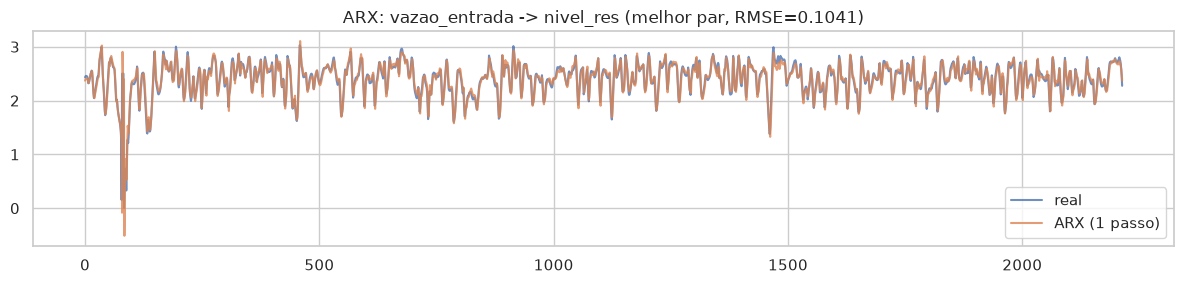

In [26]:
best = arx_df.iloc[0]
u_best, y_best = best["entrada"], best["saida"]
_, pred_best, _ = fit_arx(mimo[u_best].to_numpy(), mimo[y_best].to_numpy(), na=NA, nb=NB)
actual_best = mimo[y_best].to_numpy()[max(NA, NB):]

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(actual_best, label="real", alpha=0.8)
ax.plot(pred_best, label="ARX (1 passo)", alpha=0.8)
ax.set_title(f"ARX: {u_best} -> {y_best} (melhor par, RMSE={best['rmse_1_passo']:.4f})")
ax.legend()
fig.tight_layout()

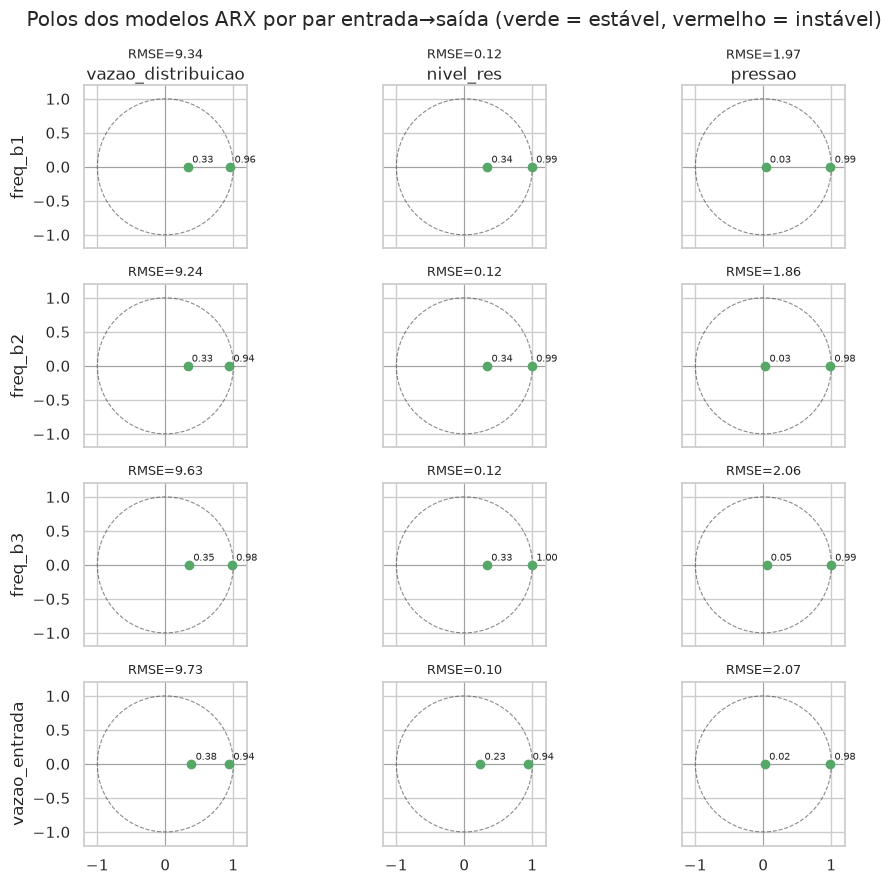

In [27]:
theta = np.linspace(0, 2 * np.pi, 200)
arx_by_pair = arx_df.set_index(["entrada", "saida"])

fig, axs = plt.subplots(
    len(INPUT_COLS), len(OUTPUT_COLS), figsize=(10, 9), sharex=True, sharey=True
)
for i, u in enumerate(INPUT_COLS):
    for j, y in enumerate(OUTPUT_COLS):
        ax = axs[i, j]
        row = arx_by_pair.loc[(u, y)]
        poles = np.asarray(row["polos"])
        color = "C2" if row["estavel"] else "C3"

        ax.plot(np.cos(theta), np.sin(theta), "k--", lw=0.8, alpha=0.5)
        ax.scatter(poles.real, poles.imag, color=color, zorder=3)
        for p in poles:
            ax.annotate(
                f"{p:.2f}", (p.real, p.imag), fontsize=7, xytext=(3, 3),
                textcoords="offset points",
            )
        ax.axhline(0, color="gray", lw=0.4)
        ax.axvline(0, color="gray", lw=0.4)
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.set_aspect("equal")
        ax.set_title(f"RMSE={row['rmse_1_passo']:.2f}", fontsize=9)
        if i == 0:
            ax.set_xlabel(y)
            ax.xaxis.set_label_position("top")
        if j == 0:
            ax.set_ylabel(u)

fig.suptitle(
    "Polos dos modelos ARX por par entrada→saída (verde = estável, vermelho = instável)"
)
fig.tight_layout()